In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")

print(merged.shape)
merged[['OBJECT_NAME', 'altitude_km', 'deltav_km_s', 'expellant_mass_kg', 'attr_mass']].dropna().head(10)

(66727, 59)


,OBJECT_NAME,altitude_km,deltav_km_s,expellant_mass_kg,attr_mass
1,VANGUARD 1,2958.830356,0.5940,0.045,1.46
3,EXPLORER 4,253.542836,0.0158,0.014,17.34
4,VANGUARD 2,2363.038666,0.4956,0.248,9.71
5,VANGUARD R/B,3259.266791,0.6392,0.755,22.79
7,VANGUARD R/B,2319.550481,0.4879,0.574,22.79
11,VANGUARD 3,2153.773720,0.4578,1.591,67.39
12,EXPLORER 7,512.094993,0.0888,0.187,41.13
18,TIROS 1,629.312944,0.1203,0.731,118.93
20,TRANSIT 1B,228.633602,0.0085,0.052,119.92
33,MIDAS 2 DEB,236.262788,0.0107,0.011,19.82


In [2]:
# hall thruster specs
# thrust is tiny but super efficient — powered by solar panels!!
THRUST_N = 0.2      # newtons (typical hall thruster)
THRUST_KMS2 = THRUST_N / 1000  # converting to km/s2

# time = (mass * delta-v) / thrust
# basically newtons second law F = ma rearranged

def deorbit_time(mass_kg, dv_km_s):
    if pd.isna(mass_kg) or pd.isna(dv_km_s):
        return np.nan
    if mass_kg <= 0 or dv_km_s <= 0:
        return np.nan
    
    # total mass including expellant
    total_mass = mass_kg + merged.loc[merged['attr_mass'] == mass_kg, 'expellant_mass_kg'].iloc[0] if not pd.isna(mass_kg) else mass_kg
    
    time_seconds = (mass_kg * dv_km_s) / THRUST_KMS2
    time_days = time_seconds / 86400
    return round(time_days, 1)

merged['attr_mass'] = pd.to_numeric(merged['attr_mass'], errors='coerce')
merged['deorbit_days'] = merged.apply(
    lambda row: deorbit_time(row['attr_mass'], row['deltav_km_s']), axis=1
)

print("deorbit time calculated for", merged['deorbit_days'].notna().sum(), "objects")
merged[['OBJECT_NAME', 'attr_mass', 'deltav_km_s', 'deorbit_days']].dropna().head(10)

deorbit time calculated for 20133 objects


,OBJECT_NAME,attr_mass,deltav_km_s,deorbit_days
1,VANGUARD 1,1.46,0.5940,0.1
3,EXPLORER 4,17.34,0.0158,0.0
4,VANGUARD 2,9.71,0.4956,0.3
5,VANGUARD R/B,22.79,0.6392,0.8
7,VANGUARD R/B,22.79,0.4879,0.6
11,VANGUARD 3,67.39,0.4578,1.8
12,EXPLORER 7,41.13,0.0888,0.2
18,TIROS 1,118.93,0.1203,0.8
20,TRANSIT 1B,119.92,0.0085,0.1
33,MIDAS 2 DEB,19.82,0.0107,0.0


In [3]:
print(merged[['deorbit_days']].dropna().describe())

print("\nfastest to deorbit:")
merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 'attr_mass', 'deorbit_days', 'risk_label']].dropna().sort_values('deorbit_days').head(10)

       deorbit_days
count  20133.000000
mean      32.812497
std       91.542494
min        0.000000
25%        1.500000
50%        2.700000
75%        7.900000
max     2797.600000

fastest to deorbit:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,attr_mass,deorbit_days,risk_label
58230,DEIMOS,PAYLOAD,4.531640e+02,2.000,0.0,MEDIUM
58229,ORESAT0.5,PAYLOAD,4.450523e+02,2.000,0.0,MEDIUM
58228,CONNECTA IOT-4,PAYLOAD,4.584878e+02,10.000,0.0,MEDIUM
58227,PTD-R (TYVAK-0127),PAYLOAD,3.556568e+02,10.000,0.0,HIGH
58225,OBJECT BF,UNKNOWN,3.970124e+02,4.000,0.0,HIGH
58224,IPERDRONE.0,PAYLOAD,4.101176e+02,12.000,0.0,HIGH
58240,LEMUR 2 MARHISYAM,PAYLOAD,5.426694e+02,7.600,0.0,MEDIUM
58239,NIGHTJAR,PAYLOAD,5.709941e+02,5.000,0.0,MEDIUM
58238,SATELIOT_2,PAYLOAD,5.924743e+02,7.407,0.0,MEDIUM
48923,HADES,PAYLOAD,2.828387e+13,0.375,0.0,HIGH


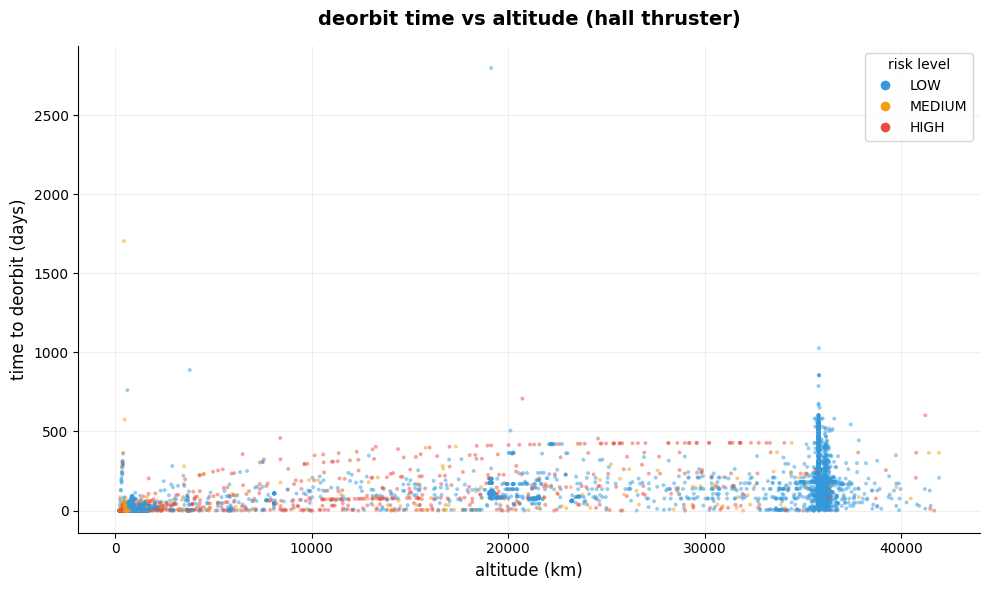

In [4]:
# deorbit time vs altitude
fig, ax = plt.subplots(figsize=(10, 6))

sample = merged[merged['altitude_km'].between(200, 42000)].dropna(subset=['deorbit_days'])
sample = sample[sample['deorbit_days'] < 10000]  # removing crazy outliers

colors = sample['risk_label'].map({'LOW': '#3498db', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'})

ax.scatter(sample['altitude_km'], sample['deorbit_days'],
           c=colors, s=8, alpha=0.5, edgecolors='none')

ax.set_title('deorbit time vs altitude (hall thruster)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('altitude (km)', fontsize=12)
ax.set_ylabel('time to deorbit (days)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='LOW'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12', markersize=8, label='MEDIUM'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='HIGH'),
]
ax.legend(handles=legend, title='risk level')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3226/3863780635.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_time = merged.groupby('regime')['deorbit_days'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()


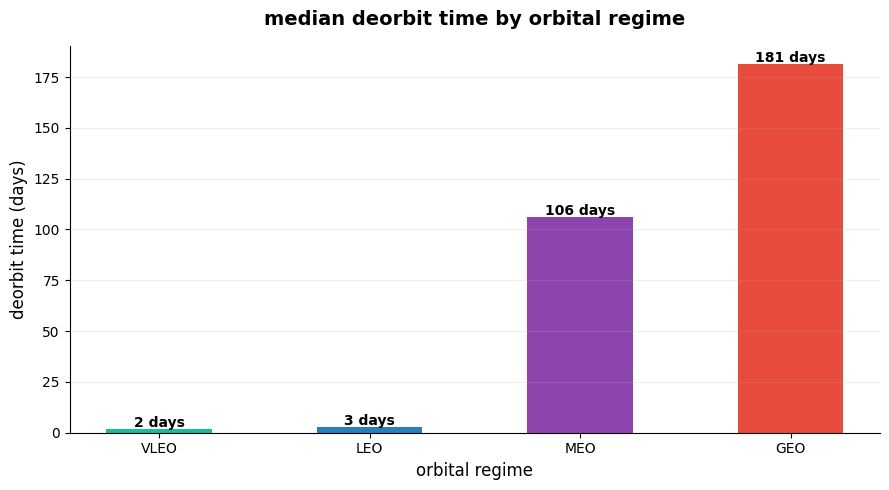

In [5]:
# median deorbit time per regime
fig, ax = plt.subplots(figsize=(9, 5))

regime_time = merged.groupby('regime')['deorbit_days'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()
colors = ['#1abc9c', '#2980b9', '#8e44ad', '#e74c3c']

bars = ax.bar(regime_time.index, regime_time.values, color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, regime_time.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f} days', ha='center', fontweight='bold', fontsize=10)

ax.set_title('median deorbit time by orbital regime', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('orbital regime', fontsize=12)
ax.set_ylabel('deorbit time (days)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [6]:
# most urgent — high risk objects and how long to deorbit them
print("high risk objects deorbit timeline:")
merged[merged['risk_label'] == 'HIGH'][['OBJECT_NAME', 'OBJECT_TYPE',
    'altitude_km', 'attr_mass', 'deltav_km_s', 'deorbit_days']].dropna().sort_values('deorbit_days').head(15)

high risk objects deorbit timeline:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,attr_mass,deltav_km_s,deorbit_days
58207,FLOCK 4BE 10,PAYLOAD,3.406210e+02,5.700,0.0409,0.0
58206,FLOCK 4BE 33,PAYLOAD,3.632849e+02,5.700,0.0474,0.0
59407,OBJECT P,UNKNOWN,4.086518e+02,3.000,0.0602,0.0
64419,OBJECT XW,UNKNOWN,3.507669e+02,10.000,0.0438,0.0
56906,OBJECT AW,UNKNOWN,3.654892e+02,1.000,0.0480,0.0
41651,POLAR SCOUT KODIAK,PAYLOAD,4.069594e+02,10.000,0.0597,0.0
64417,OBJECT XU,UNKNOWN,3.477825e+02,5.000,0.0429,0.0
64418,SILVERSAT,PAYLOAD,3.499997e+02,0.880,0.0436,0.0
41721,OBJECT D,UNKNOWN,4.126654e+02,8.000,0.0613,0.0
41692,OBJECT AZ,UNKNOWN,3.551150e+02,4.000,0.0450,0.0


In [7]:
merged.to_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet", index=False)
print("saved with deorbit times!!", merged.shape)

saved with deorbit times!! (66727, 60)
